[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%2010%20Kernel%20Methods/10-GP-Kernel-Methods.ipynb)

# Lecture 10: What Did the Data Tell Us?

Ten measurements leave a lot of room between the dots. A kernel tells us how to connect them; a Gaussian process gives us a distribution over the curves we might draw. What changes when we ask those curves to predict the future?

We'll follow real monthly Mauna Loa CO₂ measurements from the [Scripps CO₂ Program at UC San Diego](https://scrippsco2.ucsd.edu/data/primary-mauna-loa-co2-record/), then return to the image features from Lecture 9. The [historical data used here](https://github.com/jinming99/learn-ml-by-building/blob/main/Lecture%2010%20Kernel%20Methods/data/archive.csv) end in February 2017; our forecasts will be checked against measurements we deliberately hold back, not years missing from the file.

Run all cells once to activate the controls. **Explore this figure** replaces a saved plot with live controls; the saved plots also work as a read-only version on GitHub.

In [1]:
# @title Colab Setup
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    import subprocess
    repo = Path('/content/learn-ml-by-building')
    if not repo.exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/jinming99/learn-ml-by-building.git', str(repo)], check=True)
    os.chdir(repo / 'Lecture 10 Kernel Methods')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'scikit-learn', 'pandas', 'matplotlib', 'ipywidgets', 'torch', 'torchvision'], check=True)
    from google.colab import output
    output.enable_custom_widget_manager()
else:
    if Path('Lecture 10 Kernel Methods/data/archive.csv').exists():
        os.chdir('Lecture 10 Kernel Methods')
    print('Running locally. Use a kernel with scikit-learn and ipywidgets; the image extension also uses torch and torchvision.')

Running locally. Use a kernel with scikit-learn and ipywidgets; the image extension also uses torch and torchvision.


In [2]:
from functools import lru_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from IPython.utils.capture import capture_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from threadpoolctl import threadpool_limits

threadpool_limits(4)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'grid.alpha': .18, 'figure.dpi': 110, 'legend.frameon': False})
BLUE, CORAL, TEAL, INK, MUTED = '#3A86FF', '#E76F51', '#2A9D8F', '#263238', '#8D99AE'

def explore(draw, play=None, **controls):
    """One saved figure; controls update its display rather than append another."""
    with capture_output() as initial:
        draw(**{name: control.value for name, control in controls.items()})
    handles = [display(item, display_id=True) for item in initial.outputs]
    button = widgets.Button(description='Explore this figure', icon='sliders')
    def activate(_):
        live = widgets.interactive(draw, **controls)
        if play is not None:
            player = widgets.Play(min=controls[play].min, max=controls[play].max,
                                  value=controls[play].value, interval=900)
            widgets.jslink((player, 'value'), (controls[play], 'value'))
            live.children = (player,) + live.children
        handles[0].update(live)
        for handle in handles[1:]:
            handle.update(HTML(''))
        button.layout.display = 'none'
    button.on_click(activate)
    display(button)
    return button

def gp_band(ax, x, mean, std):
    ax.fill_between(np.ravel(x), mean-1.96*std, mean+1.96*std, color=BLUE, alpha=.15)
    ax.plot(x, mean, color=BLUE, lw=2.2)

## 1. How Much Can Ten Measurements Tell Us?

All three models get the same ten observations. The GP and the simple regression baseline also get an annual-cycle assumption; the neural network gets only the year. The small gray points are measurements withheld from fitting. Everything to the right of the dashed line happened after our last training observation.

Look first at the shapes, then at the errors in the future region. Which parts of the pattern could ten observations reveal on their own?

In [3]:
co2 = (pd.read_csv('data/archive.csv')
       .rename(columns={'Decimal Date': 'year', 'Carbon Dioxide (ppm)': 'co2'})
       .dropna(subset=['co2']).query('year >= 2010').sort_values('year'))
years, values = co2.year.to_numpy(), co2.co2.to_numpy()
time_x = (years-2010).reshape(-1, 1)
target_dates = np.array([2010.2, 2010.9, 2011.6, 2012.3, 2012.8,
                         2013.5, 2014.1, 2014.7, 2015.3, 2015.9])
sparse_ids = np.abs(years[:, None]-target_dates).argmin(axis=0)
assert len(np.unique(sparse_ids)) == 10
future = years > years[sparse_ids].max()
withheld = ~np.isin(np.arange(len(years)), sparse_ids)
plot_years = np.linspace(years.min(), years.max(), 400)
plot_x = (plot_years-2010).reshape(-1, 1)
print(f'{len(sparse_ids)} training observations · {withheld.sum()} withheld, including {future.sum()} in the future block')

10 training observations · 76 withheld, including 15 in the future block


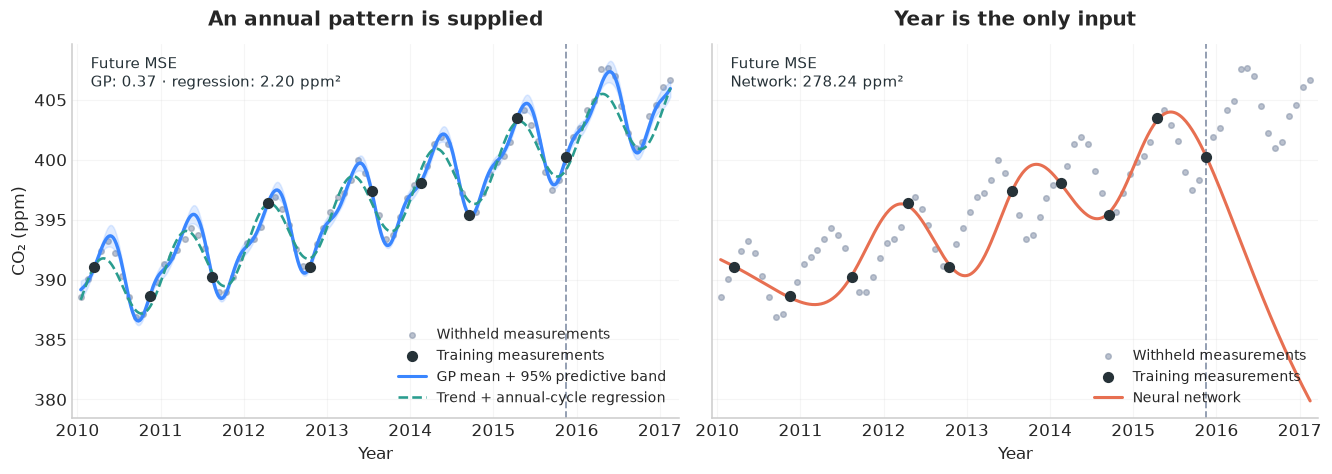

In [4]:
annual = lambda x: np.c_[x.ravel(), np.sin(2*np.pi*x.ravel()), np.cos(2*np.pi*x.ravel())]
hook_kernel = (C(1., (.01, 100))*RBF(3., (1., 30.))
               + C(1., (.01, 100))*ExpSineSquared(1., 1., (.1, 3.), 'fixed')
               + WhiteKernel(.01, (1e-5, 1.)))
hook_gp = GaussianProcessRegressor(kernel=hook_kernel, normalize_y=True, alpha=1e-6,
                                   n_restarts_optimizer=5, random_state=42).fit(time_x[sparse_ids], values[sparse_ids])
seasonal_baseline = LinearRegression().fit(annual(time_x[sparse_ids]), values[sparse_ids])
year_network = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(32, 32),
        activation='tanh', solver='lbfgs', alpha=.01, max_iter=5000, random_state=42)),
    transformer=StandardScaler()).fit(time_x[sparse_ids], values[sparse_ids])
hook_mean, hook_std = hook_gp.predict(plot_x, return_std=True)
hook_predictions = {'GP': hook_gp.predict(time_x[future]),
                    'Trend + annual cycle': seasonal_baseline.predict(annual(time_x[future])),
                    'Neural network': year_network.predict(time_x[future])}
hook_mse = {name: np.mean((pred-values[future])**2) for name, pred in hook_predictions.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True, sharey=True, layout='constrained')
for ax in axes:
    ax.scatter(years[withheld], values[withheld], s=13, color=MUTED, alpha=.6, label='Withheld measurements')
    ax.scatter(years[sparse_ids], values[sparse_ids], s=40, color=INK, zorder=5, label='Training measurements')
    ax.axvline(years[sparse_ids].max(), color=MUTED, ls='--', lw=1.2)
    ax.set(xlabel='Year', xlim=(years.min()-.1, years.max()+.1))
gp_band(axes[0], plot_years, hook_mean, hook_std)
axes[0].plot([], [], color=BLUE, lw=2, label='GP mean + 95% predictive band')
axes[0].plot(plot_years, seasonal_baseline.predict(annual(plot_x)), color=TEAL, ls='--', lw=1.7,
             label='Trend + annual-cycle regression')
axes[1].plot(plot_years, year_network.predict(plot_x), color=CORAL, lw=2, label='Neural network')
axes[0].set(title='An annual pattern is supplied', ylabel='CO₂ (ppm)')
axes[1].set_title('Year is the only input')
axes[0].text(.03, .97, f"Future MSE\nGP: {hook_mse['GP']:.2f} · regression: {hook_mse['Trend + annual cycle']:.2f} ppm²",
             transform=axes[0].transAxes, va='top', fontsize=10, color=INK)
axes[1].text(.03, .97, f"Future MSE\nNetwork: {hook_mse['Neural network']:.2f} ppm²",
             transform=axes[1].transAxes, va='top', fontsize=10, color=INK)
for ax in axes:
    ax.legend(loc='lower right', fontsize=9)
plt.show()

The annual pattern did not come from nowhere: we supplied it to two of the models. This is one small, fixed comparison, not a ranking of model families. The network has two regularized hidden layers, and we have not tuned it against these withheld observations. Its lack of a band here means we fitted a point predictor, not that neural networks cannot express uncertainty—we saw an ensemble do that in Lecture 9.

So what, exactly, did the GP assume? Let's take it apart.

## 2. The Lifting Trick, Without the Lift

In Lecture 3, a curved model became linear after we added features. A kernel can compute the inner products in that expanded space without constructing the expanded vectors. Here are two routes to the same numbers:

$$\phi(x)=[1,\sqrt{2}x_1,\sqrt{2}x_2,x_1^2,x_2^2,\sqrt{2}x_1x_2],
\qquad \phi(x)^\top\phi(z)=(1+x^\top z)^2.$$

In [5]:
points = np.array([[1., 2.], [-1., 1.], [2., 0.]])
x1, x2 = points.T
lifted = np.c_[np.ones(len(points)), np.sqrt(2)*points, x1**2, x2**2, np.sqrt(2)*x1*x2]
explicit_gram = lifted @ lifted.T
kernel_gram = (1 + points @ points.T)**2
assert np.allclose(explicit_gram, kernel_gram)
print(f'Maximum difference between the two routes: {np.max(np.abs(explicit_gram-kernel_gram)):.1e}')

Maximum difference between the two routes: 1.8e-15


Both routes compare every pair of inputs. For a GP, this same kind of matrix describes which function values tend to vary together. We can leave the high-dimensional vectors implicit and work directly with that covariance matrix.

## 3. What Does “Nearby” Mean?

The left panel follows one input: which other inputs should tell us something about its value? The right panel draws five possible functions from that assumption, **before seeing data**. These are conceptual samples, not measured CO₂ curves. Switch from an RBF kernel to a periodic kernel, and then change the length scale.

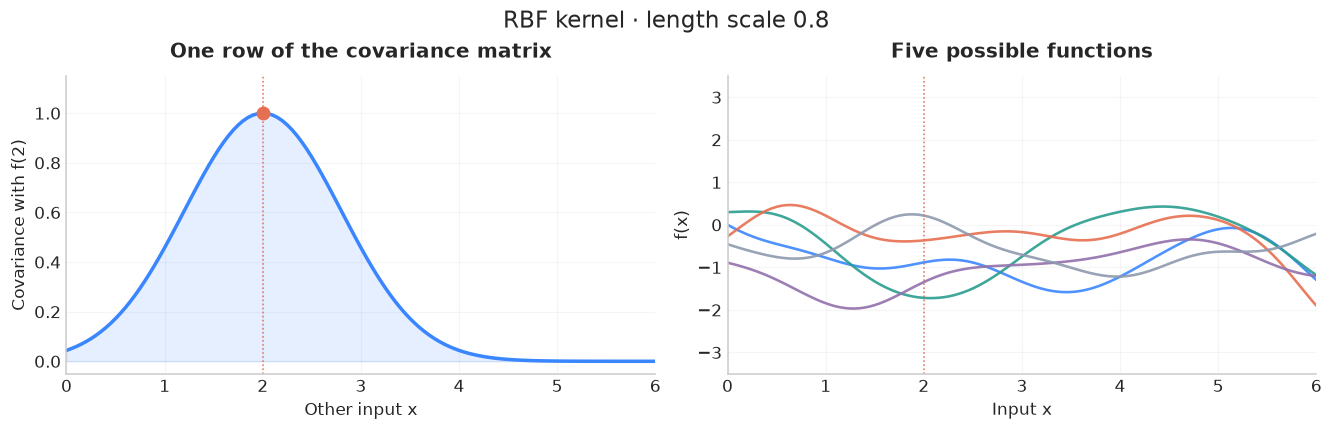

Button(description='Explore this figure', icon='sliders', style=ButtonStyle())

In [6]:
function_x = np.linspace(0, 6, 121).reshape(-1, 1)
sample_noise = np.random.default_rng(7).normal(size=(len(function_x), 5))
sample_colors = [BLUE, TEAL, CORAL, '#9270AC', MUTED]

def teaching_kernel(kind, length):
    if kind == 'Periodic':
        return ExpSineSquared(length, 2., length_scale_bounds='fixed', periodicity_bounds='fixed')
    return RBF(length, length_scale_bounds='fixed')

def kernel_story(kind='RBF', length=.8):
    kernel = teaching_kernel(kind, length)
    covariance = kernel(function_x)
    draws = np.linalg.cholesky(covariance+1e-8*np.eye(len(function_x))) @ sample_noise
    anchor = 2.
    influence = kernel(function_x, [[anchor]]).ravel()
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout='constrained')
    axes[0].fill_between(function_x.ravel(), influence, color=BLUE, alpha=.13)
    axes[0].plot(function_x, influence, color=BLUE, lw=2.3)
    axes[0].scatter([anchor], [1.], s=65, color=CORAL, zorder=5)
    axes[0].set(title='One row of the covariance matrix', xlabel='Other input x',
                ylabel='Covariance with f(2)', ylim=(-.05, 1.15), xlim=(0, 6))
    for draw, color in zip(draws.T, sample_colors):
        axes[1].plot(function_x, draw, color=color, lw=1.7, alpha=.9)
    axes[1].set(title='Five possible functions', xlabel='Input x', ylabel='f(x)',
                xlim=(0, 6), ylim=(-3.5, 3.5))
    for ax in axes:
        ax.axvline(anchor, color=CORAL, lw=1, ls=':')
    fig.suptitle(f'{kind} kernel · length scale {length:.1f}' + (' · period 2' if kind=='Periodic' else ''), fontsize=15)
    plt.show()

kernel_controls = explore(kernel_story,
    kind=widgets.ToggleButtons(options=['RBF', 'Periodic'], description='Kernel'),
    length=widgets.FloatSlider(value=.8, min=.2, max=2., step=.2, description='Length scale', continuous_update=False))

A periodic kernel can link distant inputs because they occupy the same place in a cycle. That is useful knowledge—but it is also a commitment about what will repeat. The curves are draws from a Gaussian distribution, not a claim that every imaginable function is equally likely.

## 4. Keep the Assumption. Add an Observation.

Now we hold the kernel and noise level fixed. Start the slider at zero and press play to add four illustrative observations. Watch where the mean changes and where the band narrows. Try the periodic kernel too: can an observation tell us something about a distant input?

The light curves are possible underlying functions; the band is a **95% pointwise posterior interval for f(x)**. We allow a small observation-noise standard deviation of 0.1, so the functions need not pass exactly through a dot. This is conditioning, not hyperparameter fitting.

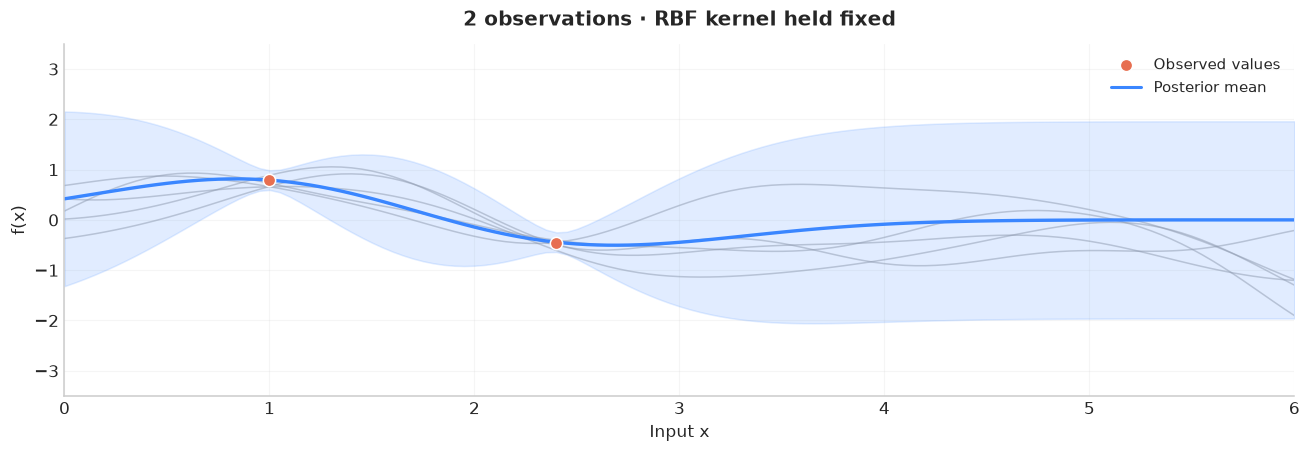

Button(description='Explore this figure', icon='sliders', style=ButtonStyle())

In [7]:
observation_x = np.array([1., 2.4, 4.1, 5.3]).reshape(-1, 1)
observation_y = np.array([.8, -.45, .6, -.7])

@lru_cache(maxsize=10)
def conditioned(kind, observations):
    model = GaussianProcessRegressor(kernel=teaching_kernel(kind, .8), alpha=.1**2,
                                     optimizer=None, normalize_y=False)
    if observations:
        model.fit(observation_x[:observations], observation_y[:observations])
    mean, covariance = model.predict(function_x, return_cov=True)
    draws = mean[:, None] + np.linalg.cholesky(covariance+1e-8*np.eye(len(function_x))) @ sample_noise
    return mean, np.sqrt(np.maximum(np.diag(covariance), 0)), draws

def conditioning_story(observations=2, kind='RBF'):
    mean, std, draws = conditioned(kind, observations)
    fig, ax = plt.subplots(figsize=(11.8, 4), layout='constrained')
    for draw in draws.T:
        ax.plot(function_x, draw, color=MUTED, lw=1, alpha=.5)
    gp_band(ax, function_x, mean, std)
    ax.scatter(observation_x[:observations], observation_y[:observations], s=65, color=CORAL,
               edgecolor='white', zorder=5, label='Observed values')
    ax.plot([], [], color=BLUE, lw=2, label='Posterior mean' if observations else 'Prior mean')
    ax.set(title=f'{observations} observations · {kind} kernel held fixed', xlabel='Input x', ylabel='f(x)',
           xlim=(0, 6), ylim=(-3.5, 3.5))
    ax.legend(loc='upper right', fontsize=10)
    plt.show()

conditioning_controls = explore(conditioning_story, play='observations',
    observations=widgets.IntSlider(value=2, min=0, max=4, description='Observations', continuous_update=False),
    kind=widgets.ToggleButtons(options=['RBF', 'Periodic'], description='Kernel'))

With Gaussian observation noise and fixed hyperparameters, the posterior follows from Gaussian conditioning. Fitting a length scale or a noise level is a separate optimization problem. We'll allow that fitting in the next experiment, using only the training observations.

## 5. Same Measurements. Different Futures.

Return to CO₂, now using every monthly observation before the cutoff. Each model gets the same training data, and each includes a learned noise term. The annual period, where present, is supplied as one year; other kernel parameters are fitted on training data only.

First compare the four forecasts without seeing the future observations. Which one would you trust, and what assumption are you trusting? Then choose **Reveal observations**, followed by **Check intervals**. We can also move the cutoff to see whether our conclusion survives a different forecasting window.

In [8]:
def co2_kernels():
    smooth = C(1., (.01, 100))*RBF(1., (.1, 10.))
    trend = C(1., (.01, 100))*DotProduct(sigma_0=1., sigma_0_bounds='fixed')
    season = C(1., (.01, 100))*ExpSineSquared(1., 1., (.2, 5.), 'fixed')
    noise = WhiteKernel(.01, (.001, 1.))
    return {'Smooth': smooth+noise, 'Smooth + trend': smooth+trend+noise,
            'Smooth + annual cycle': smooth+season+noise, 'Trend + annual cycle': trend+season+noise}

@lru_cache(maxsize=3)
def forecast_models(cutoff):
    training = years < cutoff
    assert training.any() and (~training).any()
    results = {}
    for name, kernel in co2_kernels().items():
        model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=1e-6,
                                         n_restarts_optimizer=5, random_state=42)
        model.fit(time_x[training], values[training])
        mean, std = model.predict(plot_x, return_std=True)
        pred, test_std = model.predict(time_x[~training], return_std=True)
        results[name] = dict(model=model, mean=mean, std=std, prediction=pred, test_std=test_std,
            mse=np.mean((pred-values[~training])**2),
            inside=np.abs(pred-values[~training]) <= 1.96*test_std,
            width=np.mean(3.92*test_std))
    return training, results

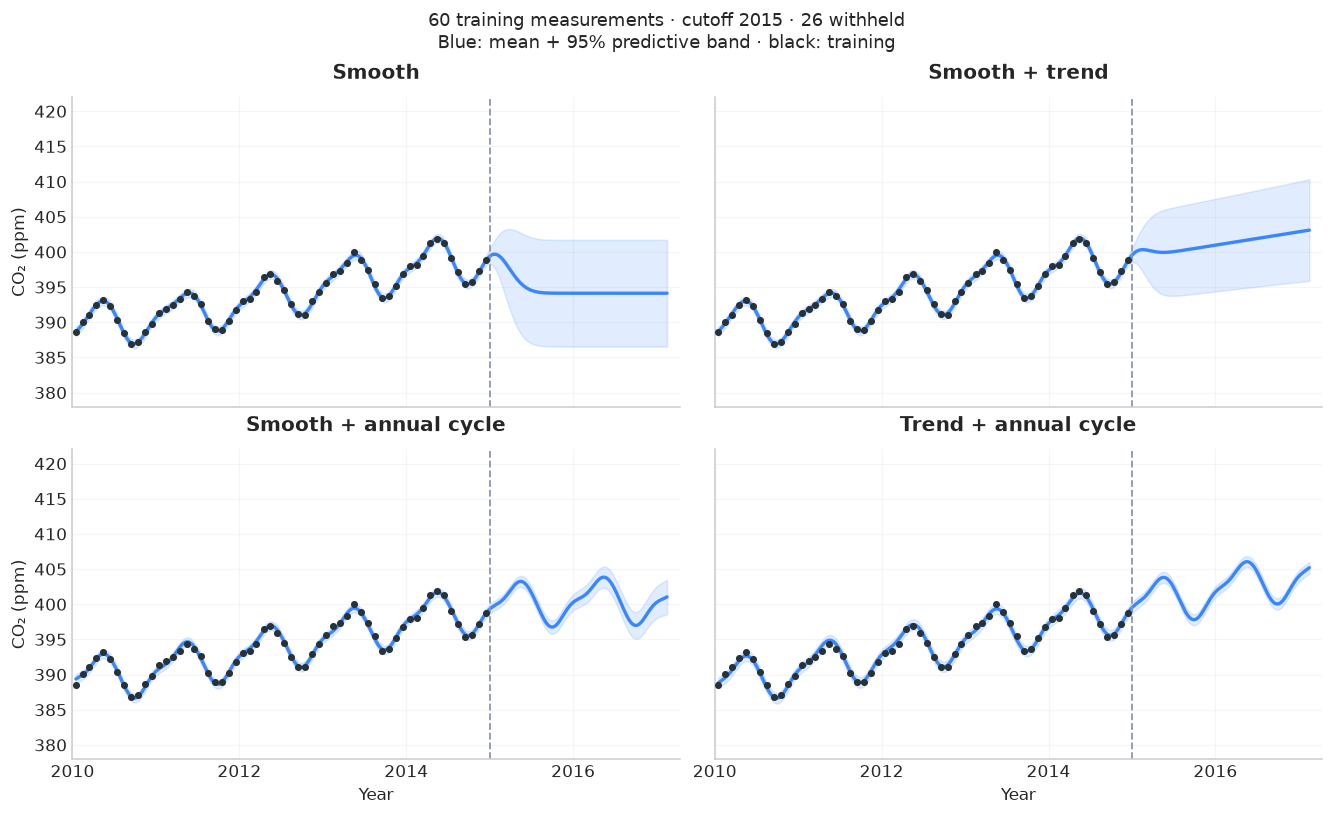

Button(description='Explore this figure', icon='sliders', style=ButtonStyle())

In [9]:
def forecast_story(view='Predict', cutoff=2015):
    training, results = forecast_models(cutoff)
    reveal, inspect = view != 'Predict', view == 'Check intervals'
    lower = min((r['mean']-1.96*r['std']).min() for r in results.values())
    upper = max((r['mean']+1.96*r['std']).max() for r in results.values())
    shared_limits = (min(378, np.floor(lower)-1), max(422, np.ceil(upper)+1))
    fig, axes = plt.subplots(2, 2, figsize=(12, 7.3), sharex=True, sharey=True, layout='constrained')
    for ax, (name, result) in zip(axes.flat, results.items()):
        gp_band(ax, plot_years, result['mean'], result['std'])
        ax.scatter(years[training], values[training], s=13, color=INK, zorder=4)
        ax.axvline(cutoff, color=MUTED, ls='--', lw=1.2)
        if reveal:
            ax.scatter(years[~training], values[~training], s=22, color=CORAL, zorder=5)
        if inspect:
            outside = ~result['inside']
            ax.scatter(years[~training][outside], values[~training][outside], s=65,
                       facecolors='none', edgecolors=CORAL, lw=1.2, zorder=6)
            text = (f"Future MSE {result['mse']:.2f} ppm²\n"
                    f"Inside band: {result['inside'].sum()}/{(~training).sum()} · mean width {result['width']:.1f} ppm")
            ax.text(.03, .97, text, transform=ax.transAxes, va='top', fontsize=9,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=.92))
        ax.set(title=name, xlim=(2010, years.max()+.15), ylim=shared_limits)
        ax.set_xticks([2010, 2012, 2014, 2016])
    axes[0, 0].set_ylabel('CO₂ (ppm)'); axes[1, 0].set_ylabel('CO₂ (ppm)')
    for ax in axes[1]:
        ax.set_xlabel('Year')
    subtitle = f'{training.sum()} training measurements · cutoff {cutoff} · {(~training).sum()} withheld'
    fig.suptitle(subtitle + '\nBlue: mean + 95% predictive band · black: training' +
                 (' · coral: withheld' if reveal else ''), fontsize=12)
    plt.show()

forecast_controls = explore(forecast_story,
    view=widgets.ToggleButtons(options=['Predict', 'Reveal observations', 'Check intervals'], description='View'),
    cutoff=widgets.SelectionSlider(options=[2014, 2015, 2016], value=2015, description='Cutoff', continuous_update=False))

**After the reveal:** fitting the observed wiggles and predicting the next cycle are different tasks. Adding kernels lets independent latent components contribute to the sum; multiplying a periodic kernel by an RBF kernel would let the repeating pattern gradually change. We do not need another fitted model to see the modeling choice: should every cycle repeat exactly, or only approximately?

**Now inspect the bands.** A forecast can be close and still miss many observations with a narrow interval. A wide interval can contain almost everything without being useful. Compare the error, the count inside, and the width together. These are pointwise predictive intervals for a future measurement, including the fitted white-noise term but not uncertainty in the fitted hyperparameters. One short, correlated time block is a diagnostic, not proof of 95% calibration.

Changing the cutoff changes both the available history and the forecast horizon. The best kernel need not stay the same. Exact GP fitting also becomes expensive as the number of observations grows: dense training uses roughly O(n³) computation and O(n²) storage, even though the feature space can be implicit.

## 6. A Different Meaning of Similarity

For images, being close in pixel space can mean having a similar background or layout, not depicting the same object. Let's compare two neighborhoods in real [CIFAR-10 images](https://www.cs.toronto.edu/~kriz/cifar.html): Euclidean distance between pixels, and distance between unit-normalized features from a frozen ImageNet-pretrained ResNet-18.

Both methods search the same 600 reference images; the 120 query images are separate. We select two queries to discuss a large change in neighbors and a remaining mismatch. Their labels help us inspect the neighborhoods, not construct the distances. These selected examples are not an accuracy benchmark or measurements of human ambiguity.

This optional extension downloads CIFAR-10 and the pretrained weights on its first run, then caches the features. It does not train a neural network or a GP.

In [10]:
import hashlib
import torch
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

torch.set_num_threads(4)
cifar = torchvision.datasets.CIFAR10('data', train=True, download=True)
all_labels = np.asarray(cifar.targets)
pool_ids, _ = train_test_split(np.arange(len(cifar)), train_size=720, stratify=all_labels, random_state=42)
reference_ids, query_ids = train_test_split(pool_ids, test_size=120, stratify=all_labels[pool_ids], random_state=42)
assert not set(reference_ids) & set(query_ids)
image_ids = np.r_[reference_ids, query_ids]
images = cifar.data[image_ids]
image_labels = all_labels[image_ids]
class_names = np.asarray(cifar.classes)
cache_dir = Path('data/kernel_cache'); cache_dir.mkdir(exist_ok=True)
version = f'resnet18-v1-official-transform:{torch.__version__}:{torchvision.__version__}'
cache_key = hashlib.sha256(version.encode()+images.tobytes()).hexdigest()[:20]
feature_path = cache_dir / f'{cache_key}.npy'
if feature_path.exists():
    image_features = np.load(feature_path, allow_pickle=False)
else:
    weights = ResNet18_Weights.IMAGENET1K_V1
    encoder = resnet18(weights=weights).eval()
    encoder.fc = torch.nn.Identity()
    chunks = []
    with torch.inference_mode():
        for start in range(0, len(images), 32):
            batch = torch.from_numpy(images[start:start+32].copy()).permute(0, 3, 1, 2)
            chunks.append(encoder(weights.transforms()(batch)).numpy())
    image_features = np.concatenate(chunks).astype('float32')
    np.save(feature_path, image_features)
pixel_vectors = images.reshape(len(images), -1).astype('float32')/255
learned_vectors = normalize(image_features)
neighbor_ids = {name: pairwise_distances(vectors[600:], vectors[:600]).argsort(axis=1)[:, :5]
                for name, vectors in [('Pixels', pixel_vectors), ('ResNet features', learned_vectors)]}
neighbor_hits = {name: (image_labels[ids] == image_labels[600:, None]).sum(axis=1)
                 for name, ids in neighbor_ids.items()}
improvement = neighbor_hits['ResNet features']-neighbor_hits['Pixels']
changed_query = int(np.argmax(improvement))
remaining = np.arange(120) != changed_query
remaining_query = int(np.flatnonzero(remaining)[np.argmin(neighbor_hits['ResNet features'][remaining])])
image_cases = {'A changed neighborhood': changed_query, 'A remaining mismatch': remaining_query}
print(f'{len(reference_ids)} reference images · {len(query_ids)} separate queries · frozen 512-dimensional features')

Files already downloaded and verified
600 reference images · 120 separate queries · frozen 512-dimensional features


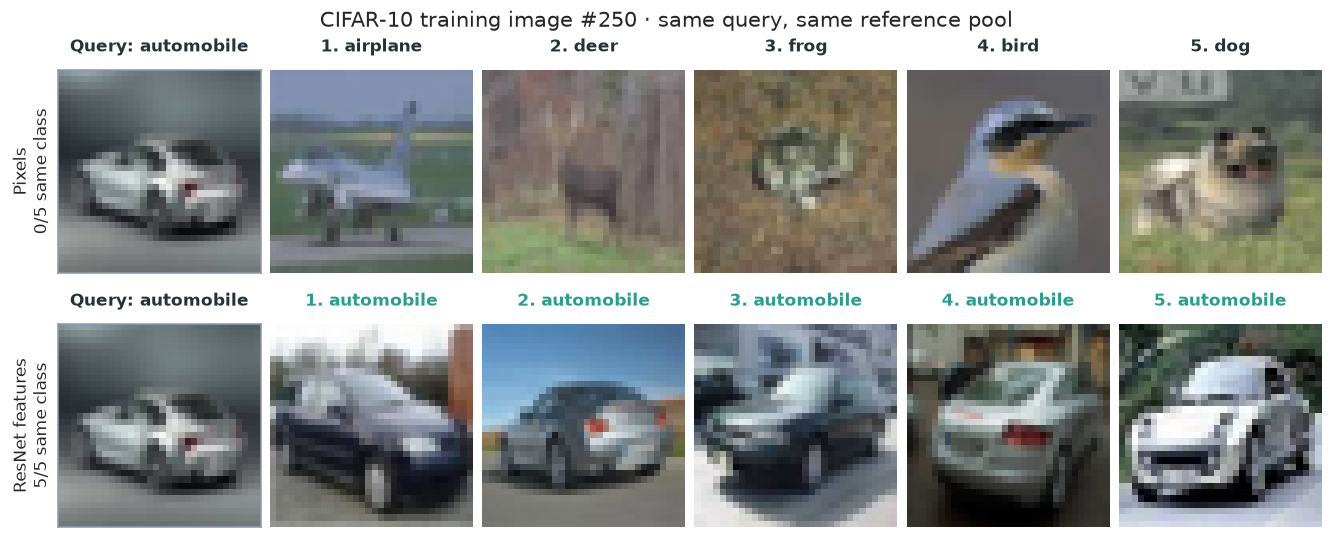

Button(description='Explore this figure', icon='sliders', style=ButtonStyle())

In [11]:
def image_story(case='A changed neighborhood'):
    query = image_cases[case]
    fig, axes = plt.subplots(2, 6, figsize=(12, 4.9), layout='constrained')
    for row, (name, neighbors) in enumerate(neighbor_ids.items()):
        ids = np.r_[600+query, neighbors[query]]
        for col, idx in enumerate(ids):
            ax = axes[row, col]
            ax.imshow(images[idx], interpolation='nearest')
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            label = class_names[image_labels[idx]]
            ax.set_title(('Query: ' if col == 0 else f'{col}. ') + label, fontsize=11,
                         color=INK if col == 0 else TEAL if image_labels[idx] == image_labels[600+query] else INK)
            for spine in ax.spines.values():
                spine.set_visible(col == 0); spine.set_color(MUTED)
        axes[row, 0].set_ylabel(f'{name}\n{neighbor_hits[name][query]}/5 same class', fontsize=11)
    fig.suptitle(f'CIFAR-10 training image #{query_ids[query]} · same query, same reference pool', fontsize=14)
    plt.show()

image_controls = explore(image_story,
    case=widgets.Dropdown(options=list(image_cases), value='A changed neighborhood', description='Example'))

We changed the representation, not the objects in the search pool. Try the second query before deciding what the learned features have solved. The green labels agree with the dataset's class; they are not a complete definition of visual similarity.

A GP can use these same frozen features through $k(x,z)=k_{\mathrm{RBF}}(h(x),h(z))$. That is a valid covariance kernel because it applies a valid kernel to a feature map; an arbitrary similarity score is not automatically valid. Here we have inspected the representation only, not demonstrated a GP's prediction quality. Jointly learning the feature extractor with the GP would be a further step.

## Wrap-Up

A kernel defines how information travels between inputs, whether they are nearby in time, at the same point in a cycle, or close in a learned representation. A Gaussian process turns that assumption into a distribution over functions and updates it when observations arrive. The kernel trick lets us work with inner products without explicitly building a large feature space, but it does not remove the cost of comparing observations. Our CO₂ forecasts showed why fitting the past, predicting the future, and expressing useful uncertainty are different achievements: each needs to be checked against data the model did not see.

Further reading: [Gaussian Processes for Machine Learning, Chapters 2 and 4](https://gaussianprocess.org/gpml/chapters/) · [scikit-learn's CO₂ example](https://scikit-learn.org/stable/auto_examples/gaussian_process/plot_gpr_co2.html) · [CIFAR-10 and its dataset report](https://www.cs.toronto.edu/~kriz/cifar.html).